<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/gaussian_gamma_unknown_mean_and_unknown_var_with_real_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== IRIS DATASET: Sepal Length Analysis ===
Dataset: 150 iris flowers
Full data - Mean: 5.843, Std: 0.825

Performing sequential Bayesian updates...


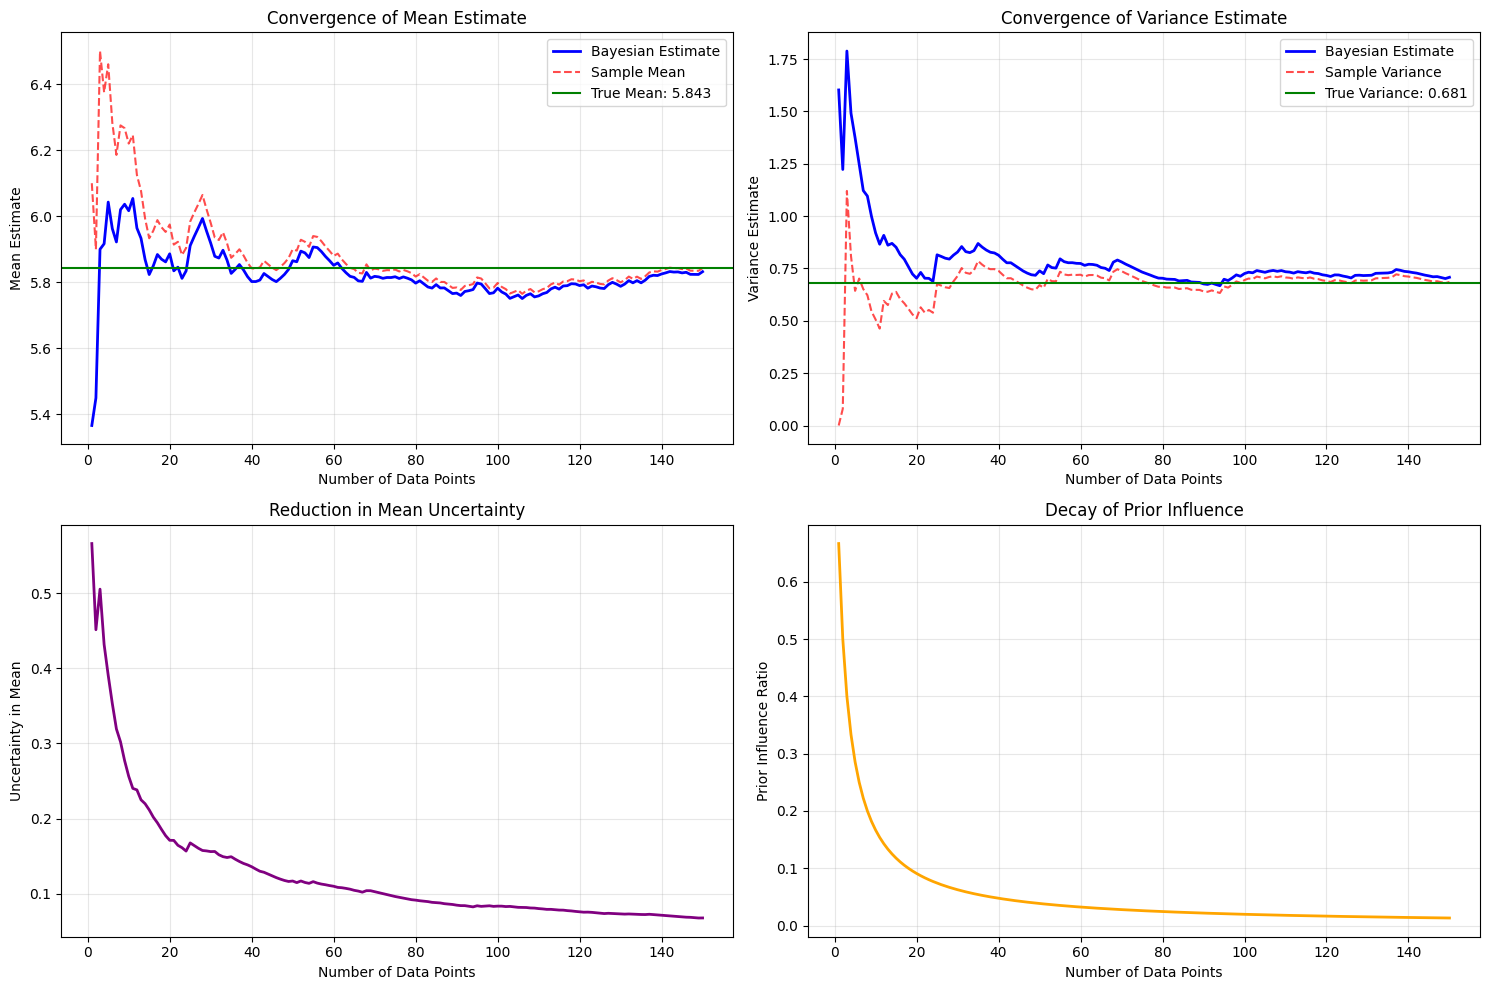

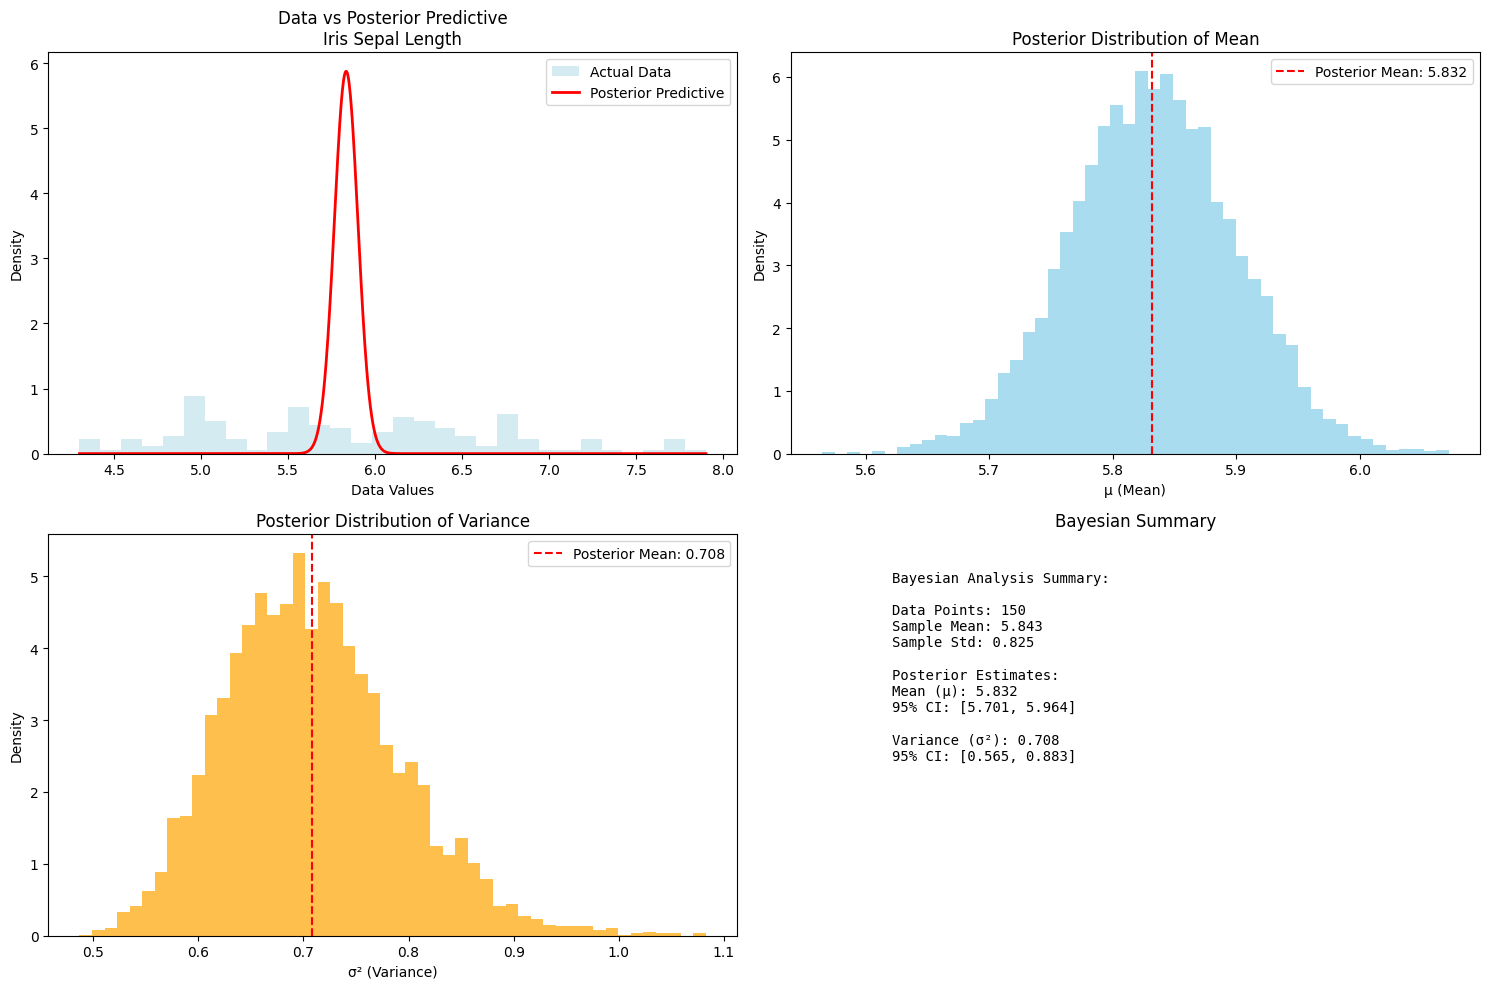


=== WINE DATASET: Alcohol Content Analysis ===
Dataset: 178 wine samples
Full data - Mean: 13.001, Std: 0.810

Performing sequential Bayesian updates...


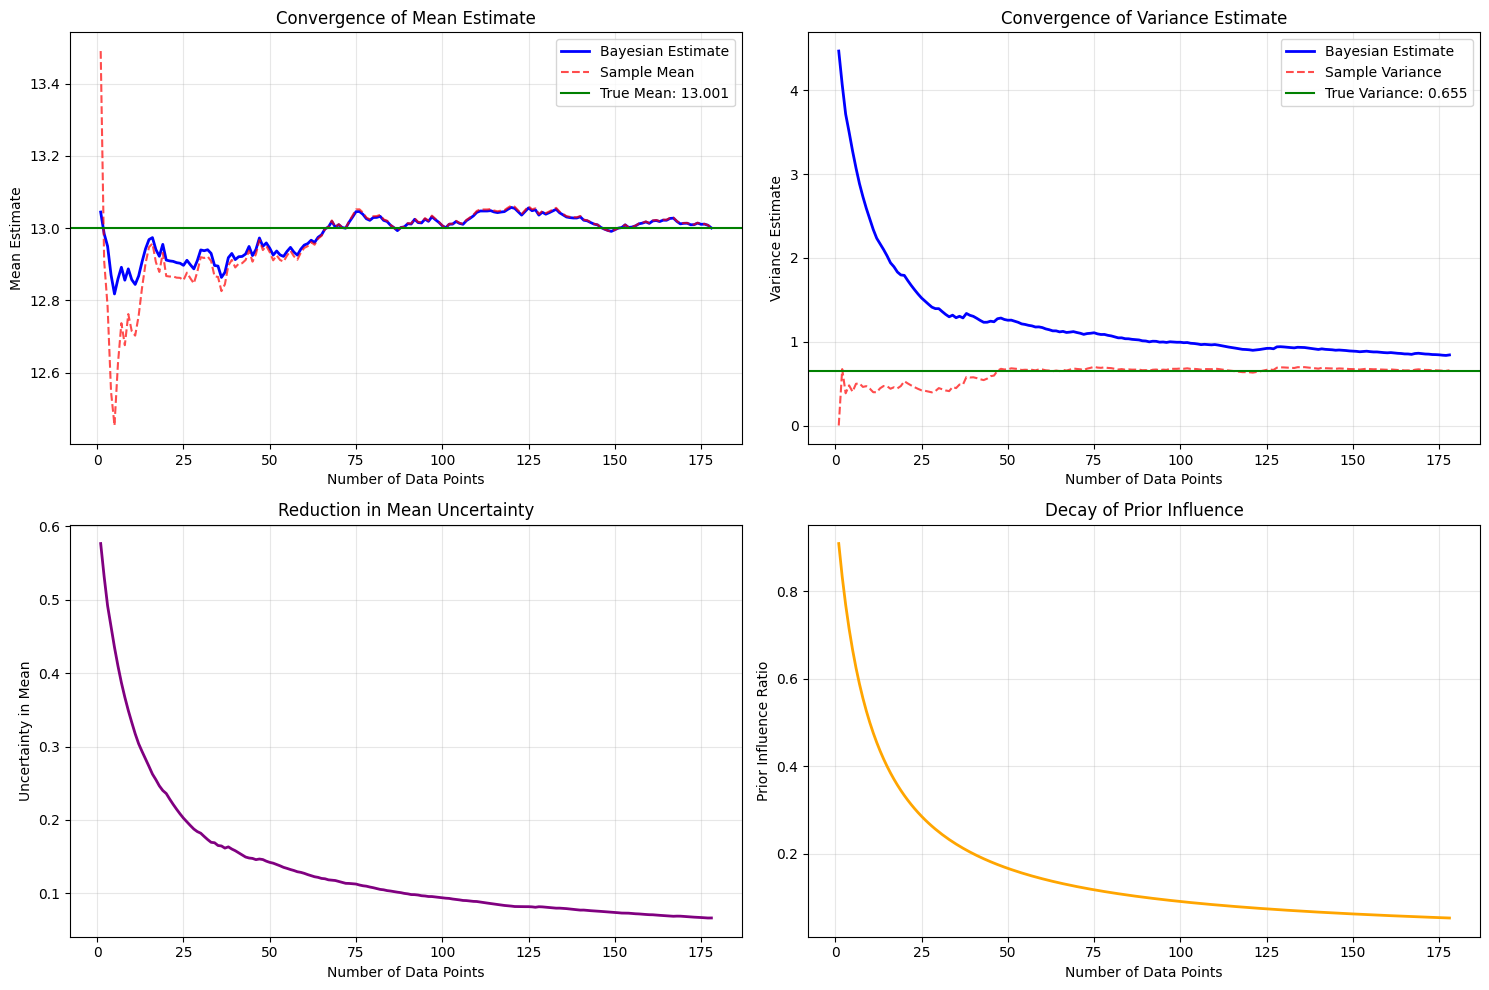

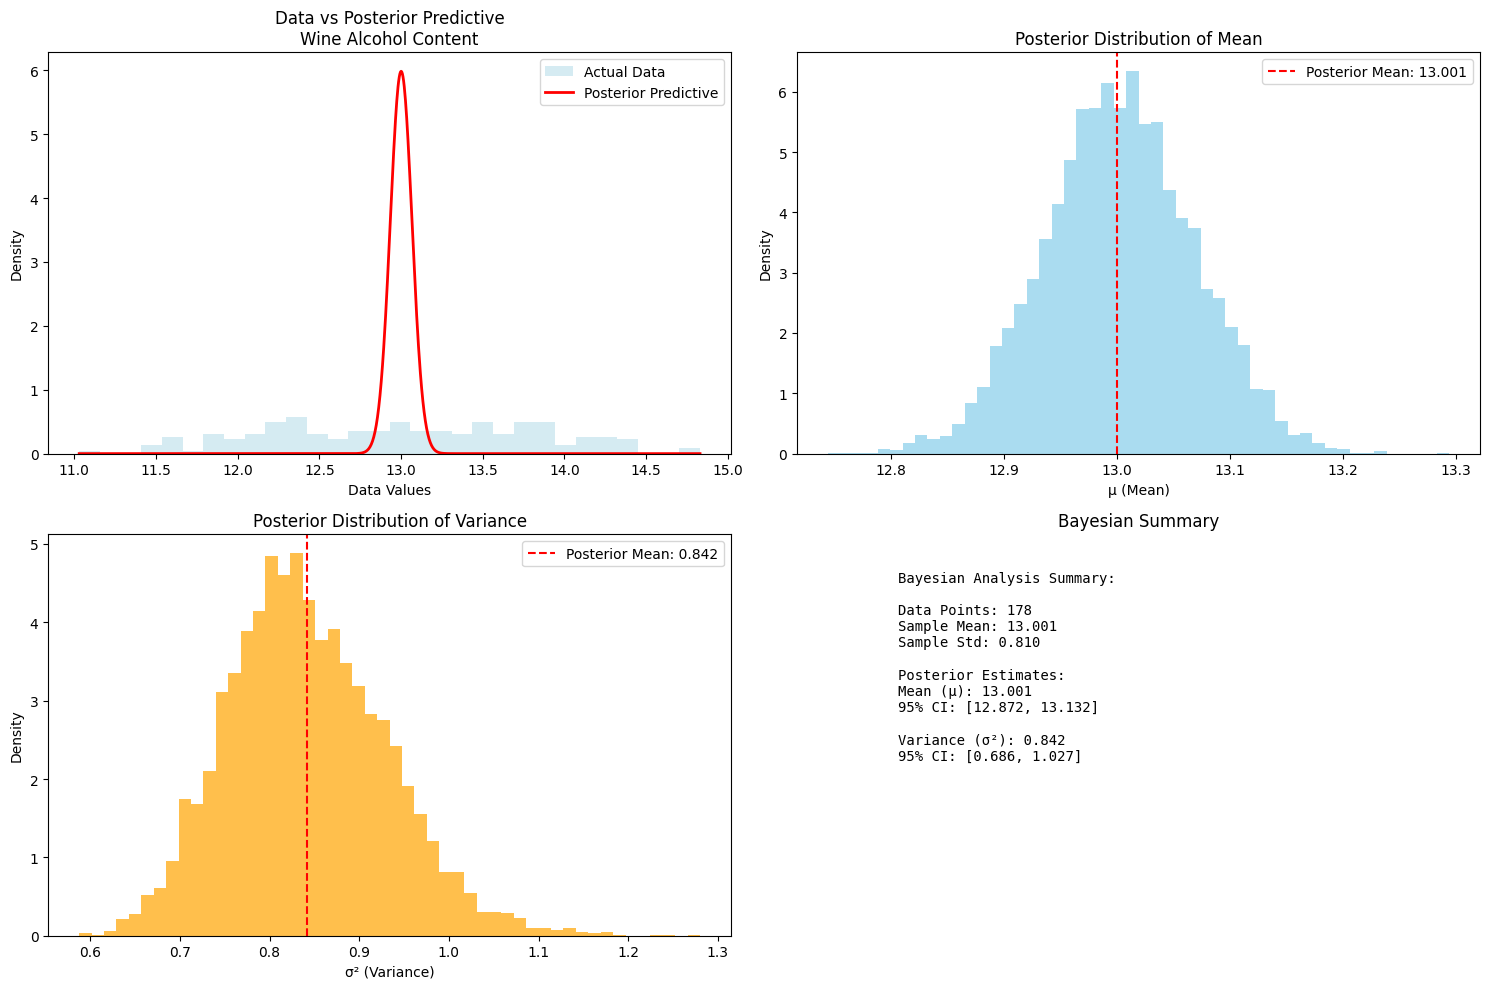


=== DIABETES DATASET: Blood Sugar Analysis ===
Dataset: 442 diabetes patients
Full data - Mean: -0.000, Std: 0.048

Performing sequential Bayesian updates...


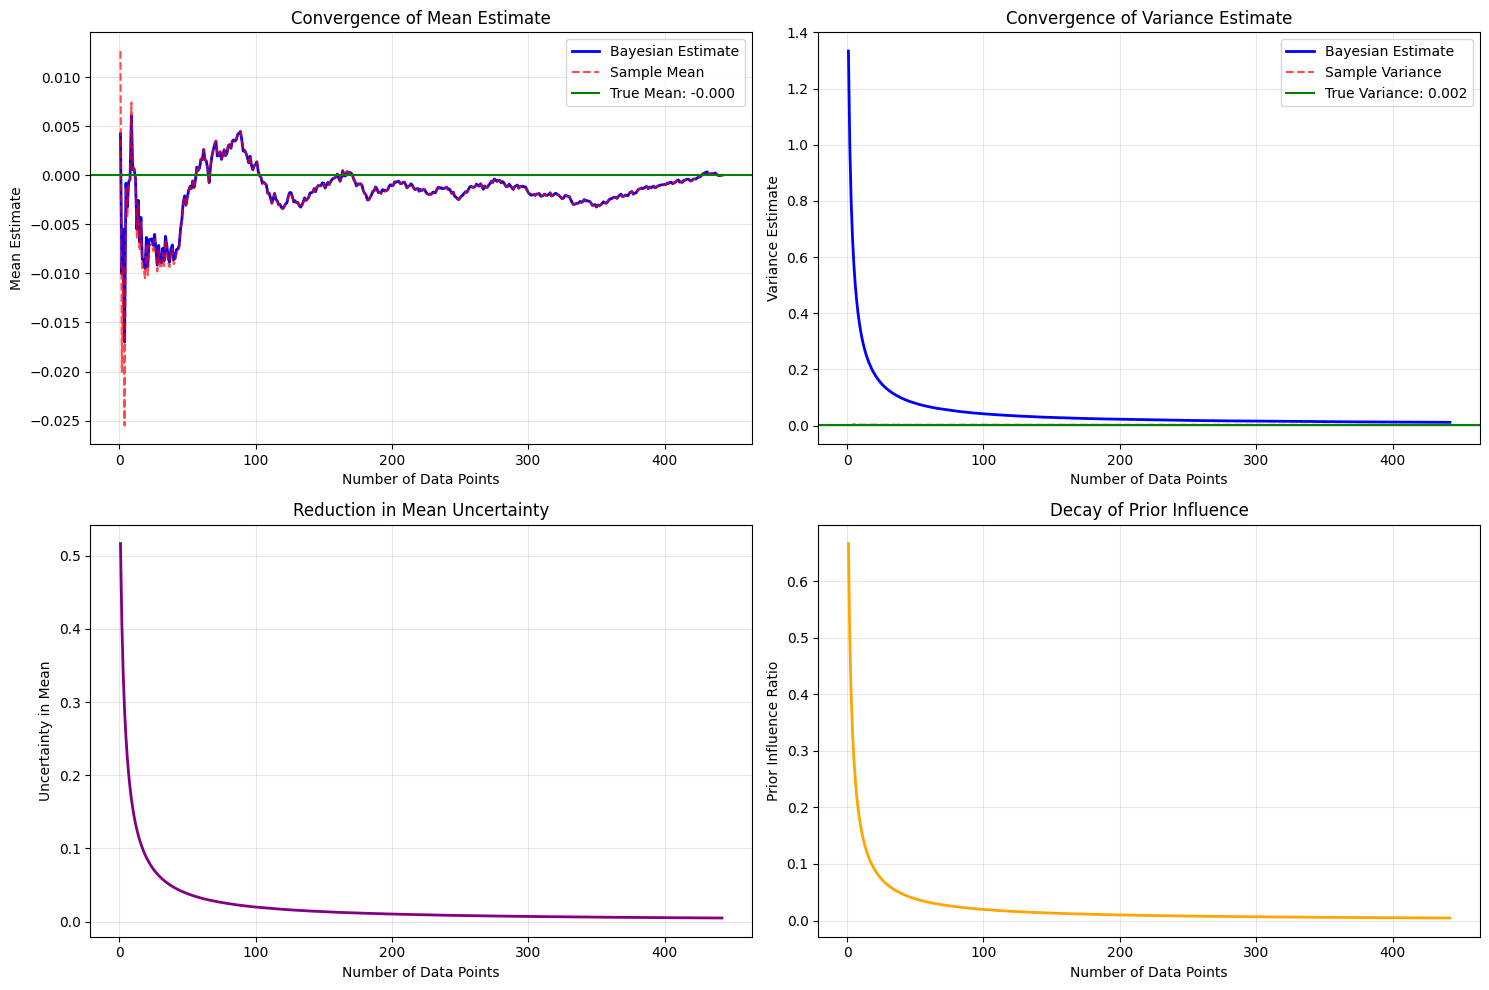

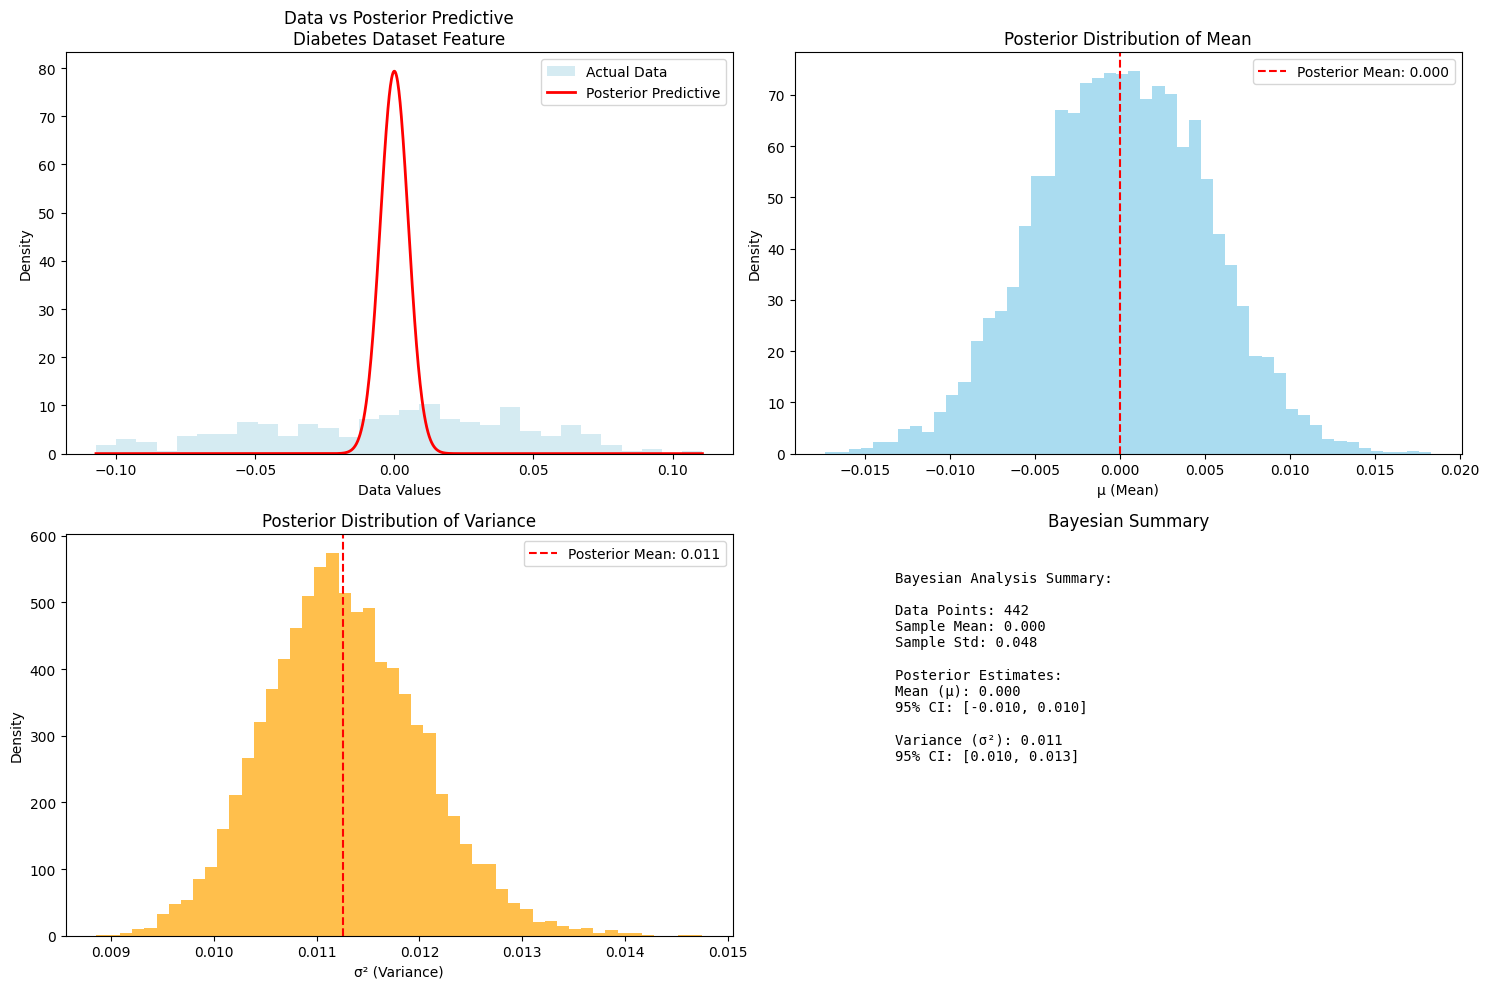


=== CUSTOM DATASET: Website Conversion Rates ===
Simulated dataset: 200 daily conversion rates
True parameters - Mean: 3.200%, Std: 0.800%

Performing sequential Bayesian updates...


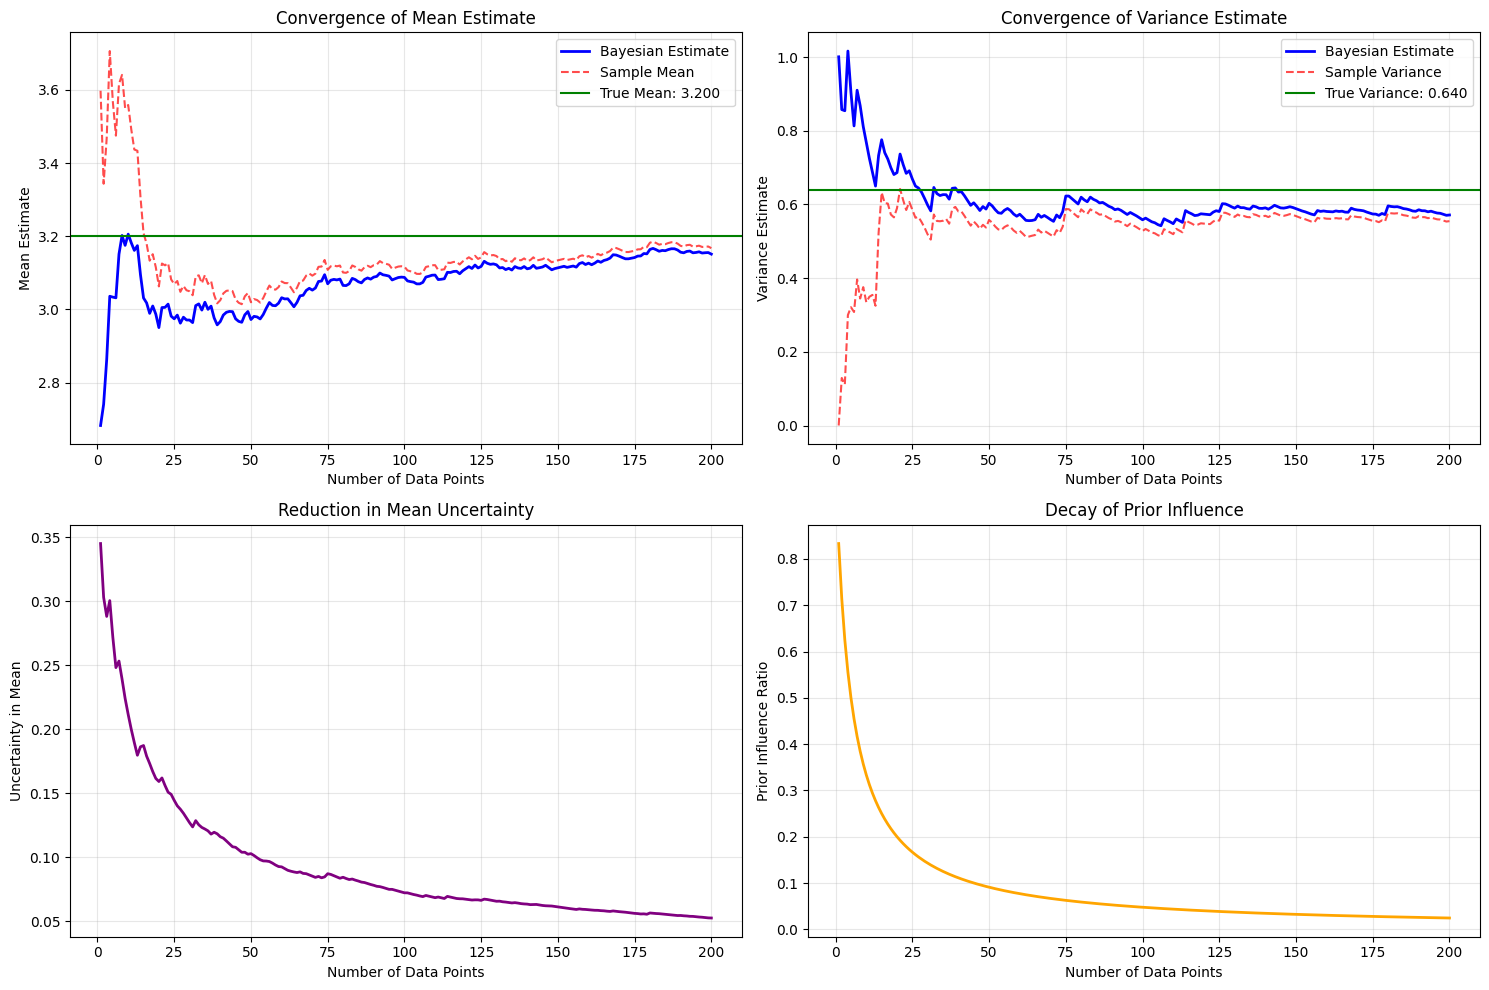

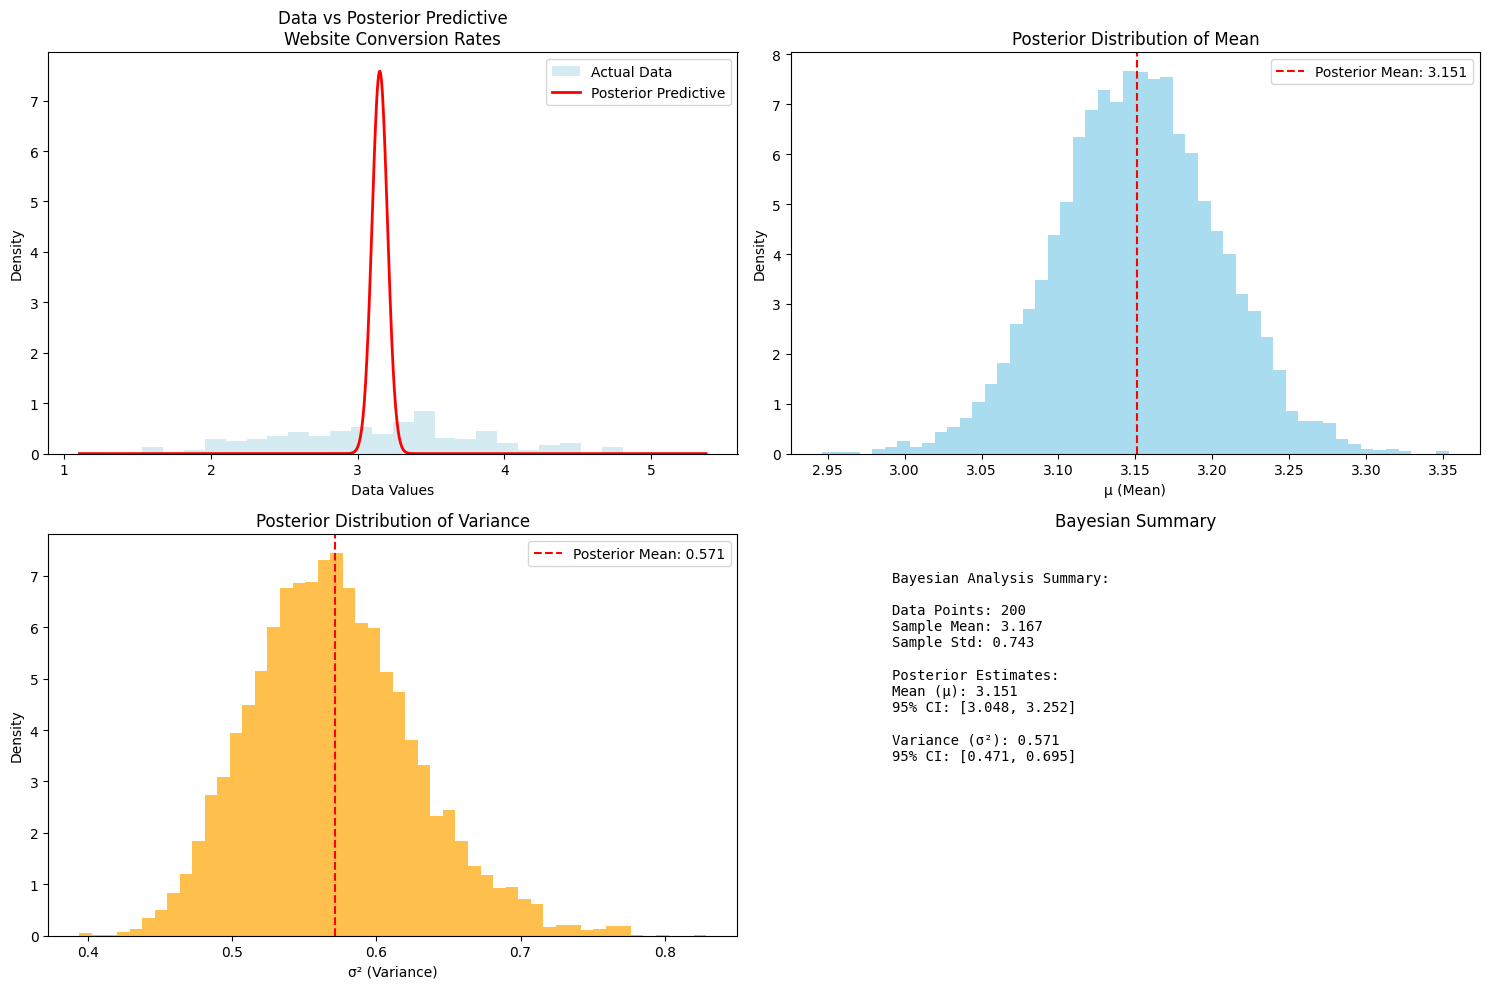


Business Insight: Probability that our conversion rate is better than industry average (2.5%): 1.000

=== PRIOR SENSITIVITY ANALYSIS ===

Testing Very Weak prior...

Testing Weak prior...

Testing Informative prior...

Testing Strong prior...


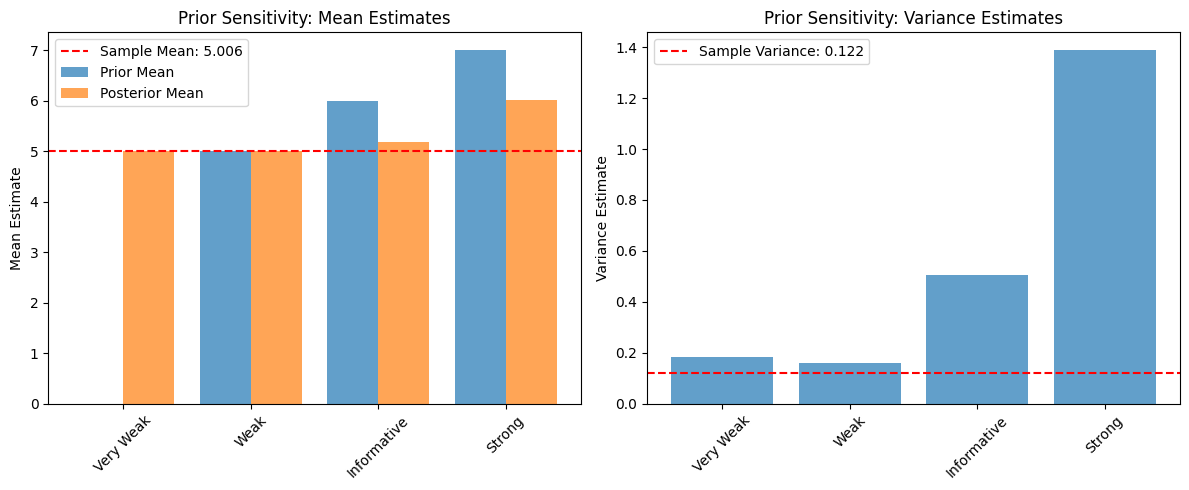


EDUCATIONAL INSIGHTS:
1. Bayesian estimates start at prior and converge to data
2. Uncertainty decreases as more data is observed
3. Prior influence decays with more data
4. Weak priors let data dominate quickly
5. Strong priors require more data to overcome
6. Posterior provides full uncertainty quantification


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import norm, gamma, t
from sklearn.datasets import load_iris, load_wine, load_diabetes
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class BayesianGaussianUnknownMeanVariance:
    """
    Bayesian inference for Gaussian with unknown mean and variance
    Using Normal-Gamma conjugate prior
    """

    def __init__(self, mu_0=0, beta=1, a=1, b=1):
        """
        Initialize with Normal-Gamma prior
        p(μ,σ²) = N(μ|μ_0, σ²/β) * Gam(1/σ²|a,b)
        """
        # Prior parameters
        self.mu_0 = mu_0      # Prior mean
        self.beta = beta      # Prior sample size for mean
        self.a = a            # Shape parameter for precision
        self.b = b            # Rate parameter for precision

        # Posterior parameters (initialize as prior)
        self.mu_N = mu_0
        self.beta_N = beta
        self.a_N = a
        self.b_N = b

        self.data = []
        self.update_history = []

    def update_posterior(self, x_new):
        """Update posterior parameters with new data"""
        self.data.append(x_new)
        N = len(self.data)
        X = np.array(self.data)

        # Sample statistics
        x_bar = np.mean(X)  # Sample mean
        S = np.sum((X - x_bar)**2)  # Sum of squares

        # Bayesian parameter updates
        self.beta_N = self.beta + N
        self.mu_N = (self.beta * self.mu_0 + N * x_bar) / self.beta_N
        self.a_N = self.a + N/2

        # b_N update with cross term for prior-data disagreement
        cross_term = (self.beta * N * (x_bar - self.mu_0)**2) / (2 * self.beta_N)
        self.b_N = self.b + 0.5 * S + cross_term

        # Store history for tracking
        self.update_history.append({
            'N': N,
            'mu_N': self.mu_N,
            'beta_N': self.beta_N,
            'a_N': self.a_N,
            'b_N': self.b_N,
            'sample_mean': x_bar,
            'sample_variance': S/(N-1) if N>1 else 0,
            'beta': self.beta # Store initial beta for plotting
        })

        return self.update_history[-1]

    def get_posterior_marginals(self):
        """Get marginal posterior distributions"""
        # Expected values
        expected_precision = self.a_N / self.b_N
        expected_variance = self.b_N / (self.a_N - 1) if self.a_N > 1 else float('inf')

        # For μ marginal (Student's t approximation)
        mu_scale = np.sqrt(self.b_N / (self.beta_N * self.a_N))  # Scale parameter
        mu_df = 2 * self.a_N  # Degrees of freedom

        return {
            'mu_mean': self.mu_N,
            'mu_std': mu_scale * np.sqrt(mu_df/(mu_df-2)) if mu_df > 2 else mu_scale,
            'precision_mean': expected_precision,
            'variance_mean': expected_variance,
            'mu_dist': (self.mu_N, mu_scale, mu_df),  # Student's t parameters
            'precision_dist': (self.a_N, self.b_N)     # Gamma parameters
        }

    def sample_posterior(self, n_samples=5000):
        """Sample from joint posterior distribution"""
        # Sample precision from Gamma posterior
        precision_samples = np.random.gamma(self.a_N, 1/self.b_N, n_samples)

        # Sample mean from conditional Gaussian
        mu_std = 1.0 / np.sqrt(self.beta_N * precision_samples)
        mu_samples = np.random.normal(self.mu_N, mu_std)

        # Convert to variance
        variance_samples = 1.0 / precision_samples

        return {
            'mu_samples': mu_samples,
            'precision_samples': precision_samples,
            'variance_samples': variance_samples
        }

    def plot_learning_process(self, true_mean=None, true_variance=None):
        """Plot how estimates converge as more data is observed"""
        history = self.update_history

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

        # Plot 1: Mean convergence
        N_values = [h['N'] for h in history]
        mu_estimates = [h['mu_N'] for h in history]
        sample_means = [h['sample_mean'] for h in history]

        ax1.plot(N_values, mu_estimates, 'b-', linewidth=2, label='Bayesian Estimate')
        ax1.plot(N_values, sample_means, 'r--', alpha=0.7, label='Sample Mean')
        if true_mean is not None:
            ax1.axhline(true_mean, color='green', linestyle='-',
                       label=f'True Mean: {true_mean:.3f}')
        ax1.set_xlabel('Number of Data Points')
        ax1.set_ylabel('Mean Estimate')
        ax1.set_title('Convergence of Mean Estimate')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Variance convergence
        variance_estimates = [h['b_N']/(h['a_N']-1) if h['a_N']>1 else float('inf')
                            for h in history]
        sample_variances = [h['sample_variance'] for h in history]

        ax2.plot(N_values, variance_estimates, 'b-', linewidth=2, label='Bayesian Estimate')
        ax2.plot(N_values, sample_variances, 'r--', alpha=0.7, label='Sample Variance')
        if true_variance is not None:
            ax2.axhline(true_variance, color='green', linestyle='-',
                       label=f'True Variance: {true_variance:.3f}')
        ax2.set_xlabel('Number of Data Points')
        ax2.set_ylabel('Variance Estimate')
        ax2.set_title('Convergence of Variance Estimate')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Plot 3: Uncertainty reduction
        mu_uncertainty = [1.0/np.sqrt(h['beta_N'] * (h['a_N']/h['b_N']))
                         for h in history]
        ax3.plot(N_values, mu_uncertainty, 'purple', linewidth=2)
        ax3.set_xlabel('Number of Data Points')
        ax3.set_ylabel('Uncertainty in Mean')
        ax3.set_title('Reduction in Mean Uncertainty')
        ax3.grid(True, alpha=0.3)

        # Plot 4: Prior influence decay
        prior_influence = [h['beta']/h['beta_N'] for h in history]
        ax4.plot(N_values, prior_influence, 'orange', linewidth=2)
        ax4.set_xlabel('Number of Data Points')
        ax4.set_ylabel('Prior Influence Ratio')
        ax4.set_title('Decay of Prior Influence')
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_final_posterior(self, data_name=""):
        """Plot final posterior distributions"""
        samples = self.sample_posterior(5000)
        marginals = self.get_posterior_marginals()

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

        # Plot 1: Data histogram with posterior predictive
        ax1.hist(self.data, bins=30, density=True, alpha=0.5,
                color='lightblue', label='Actual Data')

        # Posterior predictive distribution
        x_range = np.linspace(min(self.data), max(self.data), 1000)
        # Approximate with Student's t distribution
        mu, scale, df = marginals['mu_dist']
        predictive_pdf = t.pdf(x_range, df, loc=mu, scale=scale)
        ax1.plot(x_range, predictive_pdf, 'r-', linewidth=2,
                label='Posterior Predictive')
        ax1.set_xlabel('Data Values')
        ax1.set_ylabel('Density')
        ax1.set_title(f'Data vs Posterior Predictive\n{data_name}')
        ax1.legend()

        # Plot 2: Mean posterior
        ax2.hist(samples['mu_samples'], bins=50, density=True,
                alpha=0.7, color='skyblue')
        ax2.axvline(marginals['mu_mean'], color='red', linestyle='--',
                   label=f'Posterior Mean: {marginals["mu_mean"]:.3f}')
        ax2.set_xlabel('μ (Mean)')
        ax2.set_ylabel('Density')
        ax2.set_title('Posterior Distribution of Mean')
        ax2.legend()

        # Plot 3: Variance posterior
        ax3.hist(samples['variance_samples'], bins=50, density=True,
                alpha=0.7, color='orange')
        ax3.axvline(marginals['variance_mean'], color='red', linestyle='--',
                   label=f'Posterior Mean: {marginals["variance_mean"]:.3f}')
        ax3.set_xlabel('σ² (Variance)')
        ax3.set_ylabel('Density')
        ax3.set_title('Posterior Distribution of Variance')
        ax3.legend()

        # Plot 4: Summary statistics
        mu_ci = np.percentile(samples['mu_samples'], [2.5, 97.5])
        var_ci = np.percentile(samples['variance_samples'], [2.5, 97.5])

        summary_text = f"""
        Bayesian Analysis Summary:

        Data Points: {len(self.data)}
        Sample Mean: {np.mean(self.data):.3f}
        Sample Std: {np.std(self.data):.3f}

        Posterior Estimates:
        Mean (μ): {marginals['mu_mean']:.3f}
        95% CI: [{mu_ci[0]:.3f}, {mu_ci[1]:.3f}]

        Variance (σ²): {marginals['variance_mean']:.3f}
        95% CI: [{var_ci[0]:.3f}, {var_ci[1]:.3f}]
        """

        ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
                fontfamily='monospace', verticalalignment='top', fontsize=10)
        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.axis('off')
        ax4.set_title('Bayesian Summary')

        plt.tight_layout()
        plt.show()

        return marginals

# Real Dataset Demonstrations
def demonstrate_iris_dataset():
    """Bayesian analysis on Iris dataset"""
    print("=== IRIS DATASET: Sepal Length Analysis ===")
    iris = load_iris()
    data = iris.data[:, 0]  # Sepal length

    print(f"Dataset: {len(data)} iris flowers")
    print(f"Full data - Mean: {np.mean(data):.3f}, Std: {np.std(data):.3f}")

    # Initialize with weak priors
    bayesian_model = BayesianGaussianUnknownMeanVariance(
        mu_0=5.0,    # Rough guess for sepal length
        beta=2,      # Weak prior
        a=2,         # Weak prior
        b=2          # Weak prior
    )

    # Sequential updates (shuffle data to simulate real learning)
    np.random.seed(42)
    shuffled_data = np.random.permutation(data)

    print("\nPerforming sequential Bayesian updates...")
    for i, x in enumerate(shuffled_data):
        bayesian_model.update_posterior(x)

    # Plot results
    true_mean = np.mean(data)
    true_variance = np.var(data)
    bayesian_model.plot_learning_process(true_mean, true_variance)
    marginals = bayesian_model.plot_final_posterior("Iris Sepal Length")

    return bayesian_model

def demonstrate_wine_dataset():
    """Bayesian analysis on Wine dataset"""
    print("\n=== WINE DATASET: Alcohol Content Analysis ===")
    wine = load_wine()
    data = wine.data[:, 0]  # Alcohol content

    print(f"Dataset: {len(data)} wine samples")
    print(f"Full data - Mean: {np.mean(data):.3f}, Std: {np.std(data):.3f}")

    # Use more informative priors based on wine knowledge
    bayesian_model = BayesianGaussianUnknownMeanVariance(
        mu_0=13.0,   # Typical wine alcohol content
        beta=10,     # Moderate prior strength
        a=5,         # Moderate prior
        b=20         # Based on expected variance
    )

    # Sequential updates
    np.random.seed(123)
    shuffled_data = np.random.permutation(data)

    print("\nPerforming sequential Bayesian updates...")
    for i, x in enumerate(shuffled_data):
        bayesian_model.update_posterior(x)

    # Plot results
    true_mean = np.mean(data)
    true_variance = np.var(data)
    bayesian_model.plot_learning_process(true_mean, true_variance)
    marginals = bayesian_model.plot_final_posterior("Wine Alcohol Content")

    return bayesian_model

def demonstrate_diabetes_dataset():
    """Bayesian analysis on Diabetes dataset"""
    print("\n=== DIABETES DATASET: Blood Sugar Analysis ===")
    diabetes = load_diabetes()
    data = diabetes.data[:, 0]  # First feature (age)

    print(f"Dataset: {len(data)} diabetes patients")
    print(f"Full data - Mean: {np.mean(data):.3f}, Std: {np.std(data):.3f}")

    # Initialize with weak priors
    bayesian_model = BayesianGaussianUnknownMeanVariance(
        mu_0=0.0,    # Standardized data
        beta=2,      # Weak prior
        a=2,         # Weak prior
        b=2          # Weak prior
    )

    # Sequential updates
    np.random.seed(456)
    shuffled_data = np.random.permutation(data)

    print("\nPerforming sequential Bayesian updates...")
    for i, x in enumerate(shuffled_data):
        bayesian_model.update_posterior(x)

    # Plot results
    true_mean = np.mean(data)
    true_variance = np.var(data)
    bayesian_model.plot_learning_process(true_mean, true_variance)
    marginals = bayesian_model.plot_final_posterior("Diabetes Dataset Feature")

    return bayesian_model

def demonstrate_custom_dataset():
    """Bayesian analysis on custom dataset (simulated business metrics)"""
    print("\n=== CUSTOM DATASET: Website Conversion Rates ===")

    # Simulate realistic conversion rate data (percentage)
    np.random.seed(42)
    true_conversion_rate = 3.2  # 3.2% conversion rate
    true_std = 0.8
    data = np.random.normal(true_conversion_rate, true_std, 200)
    data = np.clip(data, 0, 10)  # Keep realistic conversion rates

    print(f"Simulated dataset: {len(data)} daily conversion rates")
    print(f"True parameters - Mean: {true_conversion_rate:.3f}%, Std: {true_std:.3f}%")

    # Business-informed priors
    bayesian_model = BayesianGaussianUnknownMeanVariance(
        mu_0=2.5,    # Industry average conversion rate
        beta=5,      # Based on industry benchmarks
        a=3,         # Moderate confidence in variance estimate
        b=2          # Based on industry variance
    )

    print("\nPerforming sequential Bayesian updates...")
    for i, x in enumerate(data):
        bayesian_model.update_posterior(x)

    # Plot results
    bayesian_model.plot_learning_process(true_conversion_rate, true_std**2)
    marginals = bayesian_model.plot_final_posterior("Website Conversion Rates")

    # Business insights
    samples = bayesian_model.sample_posterior(10000)
    prob_better_than_industry = np.mean(samples['mu_samples'] > 2.5)
    print(f"\nBusiness Insight: Probability that our conversion rate is better than industry average (2.5%): {prob_better_than_industry:.3f}")

    return bayesian_model

def compare_prior_sensitivity():
    """Compare different prior choices on the same dataset"""
    print("\n=== PRIOR SENSITIVITY ANALYSIS ===")

    # Use Iris dataset
    iris = load_iris()
    data = iris.data[:, 0]
    test_data = data[:50]  # Use first 50 points for demonstration

    priors = {
        'Very Weak': {'mu_0': 0, 'beta': 0.1, 'a': 0.1, 'b': 0.1},
        'Weak': {'mu_0': 5, 'beta': 1, 'a': 1, 'b': 1},
        'Informative': {'mu_0': 6, 'beta': 10, 'a': 10, 'b': 10},
        'Strong': {'mu_0': 7, 'beta': 50, 'a': 50, 'b': 50}
    }

    results = {}
    for prior_name, prior_params in priors.items():
        print(f"\nTesting {prior_name} prior...")
        model = BayesianGaussianUnknownMeanVariance(**prior_params)

        for x in test_data:
            model.update_posterior(x)

        marginals = model.get_posterior_marginals()
        results[prior_name] = {
            'final_mu': marginals['mu_mean'],
            'final_variance': marginals['variance_mean'],
            'prior_mu': prior_params['mu_0']
        }

    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    names = list(results.keys())
    final_means = [results[name]['final_mu'] for name in names]
    prior_means = [results[name]['prior_mu'] for name in names]

    x_pos = np.arange(len(names))
    ax1.bar(x_pos - 0.2, prior_means, 0.4, label='Prior Mean', alpha=0.7)
    ax1.bar(x_pos + 0.2, final_means, 0.4, label='Posterior Mean', alpha=0.7)
    ax1.axhline(np.mean(test_data), color='red', linestyle='--',
               label=f'Sample Mean: {np.mean(test_data):.3f}')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(names, rotation=45)
    ax1.set_ylabel('Mean Estimate')
    ax1.set_title('Prior Sensitivity: Mean Estimates')
    ax1.legend()

    final_variances = [results[name]['final_variance'] for name in names]
    ax2.bar(names, final_variances, alpha=0.7)
    ax2.axhline(np.var(test_data), color='red', linestyle='--',
               label=f'Sample Variance: {np.var(test_data):.3f}')
    ax2.set_ylabel('Variance Estimate')
    ax2.set_title('Prior Sensitivity: Variance Estimates')
    ax2.legend()
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    return results

if __name__ == "__main__":
    # Run all demonstrations
    iris_model = demonstrate_iris_dataset()
    wine_model = demonstrate_wine_dataset()
    diabetes_model = demonstrate_diabetes_dataset()
    business_model = demonstrate_custom_dataset()
    sensitivity_results = compare_prior_sensitivity()

    print("\n" + "="*60)
    print("EDUCATIONAL INSIGHTS:")
    print("="*60)
    print("1. Bayesian estimates start at prior and converge to data")
    print("2. Uncertainty decreases as more data is observed")
    print("3. Prior influence decays with more data")
    print("4. Weak priors let data dominate quickly")
    print("5. Strong priors require more data to overcome")
    print("6. Posterior provides full uncertainty quantification")
    print("="*60)